Call Option Price: 8.021352235143176
Put Option Price: 7.9004418077181455
Delta Call: 0.5422283335848053
Delta Put: -0.45777166641519473
Gamma: 0.019835261904213263
Vega: 39.67052380842653


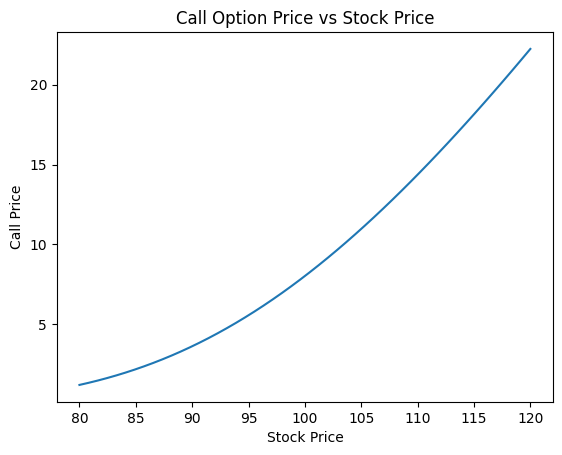

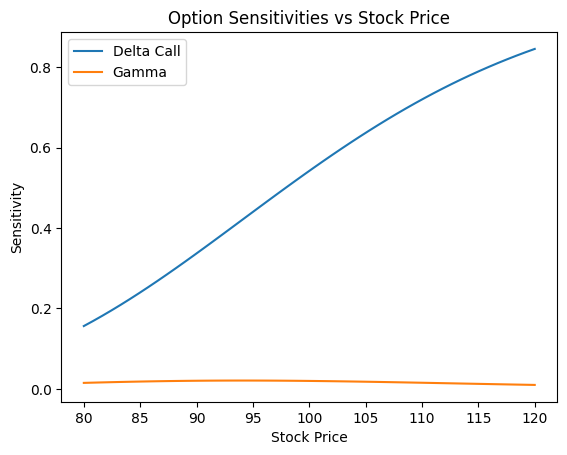

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

S = 100      # Current stock price
K = 105      # Strike price
T = 1        # Time to maturity (1 year)
r = 0.05     # Risk-free rate
sigma = 0.2  # Volatility

def black_scholes_call(S, K, T, r, sigma):
    """Price of a European Call Option"""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2)*T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_price = S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
    return call_price

call = black_scholes_call(S, K, T, r, sigma)
put = black_scholes_put(S, K, T, r, sigma)

print("Call Option Price:", call)
print("Put Option Price:", put)
def greeks(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2)*T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    delta_call = norm.cdf(d1)
    delta_put = delta_call - 1
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega = S * norm.pdf(d1) * np.sqrt(T)

    return delta_call, delta_put, gamma, vega

delta_call, delta_put, gamma, vega = greeks(S, K, T, r, sigma)
print("Delta Call:", delta_call)
print("Delta Put:", delta_put)
print("Gamma:", gamma)
print("Vega:", vega)
S_range = np.linspace(80, 120, 50)
call_prices = [black_scholes_call(s, K, T, r, sigma) for s in S_range]

plt.plot(S_range, call_prices)
plt.title("Call Option Price vs Stock Price")
plt.xlabel("Stock Price")
plt.ylabel("Call Price")
plt.show()

S_range = np.linspace(80, 120, 50)
delta_values = [greeks(s, K, T, r, sigma)[0] for s in S_range]
gamma_values = [greeks(s, K, T, r, sigma)[2] for s in S_range]

plt.plot(S_range, delta_values, label='Delta Call')
plt.plot(S_range, gamma_values, label='Gamma')
plt.title('Option Sensitivities vs Stock Price')
plt.xlabel('Stock Price')
plt.ylabel('Sensitivity')
plt.legend()
plt.show()
# Black-Scholes Option Pricing Engine


# Black-Scholes Option Pricing Engine

## Overview
This notebook implements a European call and put option pricing engine using the Black-Scholes model.
It also calculates Greeks (Delta, Gamma, Vega) and visualizes sensitivities to the underlying stock price.

## Features
- Call & Put pricing
- Greeks calculation
- Visualizations of Price vs Stock & Sensitivities
- Interactive exploration possible in Jupyter/Colab

## Insights
- Option prices increase with stock price
- Delta measures how option price changes with stock price
- Gamma measures curvature and risk of rapid change
- Vega shows sensitivity to volatility